# Comprehensive Comparison: Rectified Flow vs Diffusion Models

This notebook provides a comprehensive comparison between Rectified Flow and Diffusion-based approaches:

## Models Compared
1. **DDPM (Pixel Space)**: Original diffusion model with 1000 steps
2. **DDIM (Pixel Space)**: Fast diffusion sampling with fewer steps
3. **Rectified Flow (Pixel Space)**: Straight-line ODE paths
4. **LDM (Latent Space)**: Latent Diffusion Model with VAE
5. **Latent RF (Latent Space)**: Rectified Flow in VAE latent space

## Evaluation Criteria
- **Convergence Speed**: Training loss curves and epochs to convergence
- **Sample Quality**: Visual comparison and diversity
- **Inference Speed**: Time per sample at different step counts
- **Training Stability**: Loss variance and gradient behavior

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import time
import glob
from pathlib import Path

from ddpm import DDPM
from rectified_flow import RectifiedFlow, LatentRectifiedFlow
from ldm import LatentDiffusionModel
from vae.model import VariationalAutoencoder

import warnings
warnings.filterwarnings('ignore')

## 1. Load All Trained Models

Load the best checkpoints for each model.

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}\n")

models = {}

# Load DDPM
ddpm_ckpt = glob.glob('../data/saved_models/ddpm/*.ckpt')
if ddpm_ckpt:
    print(f"Loading DDPM from: {ddpm_ckpt[-1]}")
    models['DDPM'] = DDPM.load_from_checkpoint(ddpm_ckpt[-1]).to(device).eval()
else:
    print("⚠ DDPM checkpoint not found")

# Load Rectified Flow (pixel space)
rf_ckpt = glob.glob('../data/saved_models/rectified_flow/*.ckpt')
if rf_ckpt:
    print(f"Loading Rectified Flow from: {rf_ckpt[-1]}")
    models['RF'] = RectifiedFlow.load_from_checkpoint(rf_ckpt[-1]).to(device).eval()
else:
    print("⚠ Rectified Flow checkpoint not found")

# Load VAE (needed for latent models)
vae_ckpt = glob.glob('../lightning_logs/vae_quick/version_0/checkpoints/*.ckpt')
if vae_ckpt:
    print(f"Loading VAE from: {vae_ckpt[-1]}")
    vae = VariationalAutoencoder.load_from_checkpoint(vae_ckpt[-1]).to(device).eval()
    
    # Load LDM
    ldm_ckpt = glob.glob('../lightning_logs/ldm_mnist/version_1/checkpoints/*.ckpt')
    if ldm_ckpt:
        print(f"Loading LDM from: {ldm_ckpt[-1]}")
        models['LDM'] = LatentDiffusionModel.load_from_checkpoint(
            ldm_ckpt[-1], vae_model=vae
        ).to(device).eval()
    else:
        print("⚠ LDM checkpoint not found")
    
    # Load Latent RF
    lrf_ckpt = glob.glob('../data/saved_models/latent_rectified_flow/*.ckpt')
    if lrf_ckpt:
        print(f"Loading Latent RF from: {lrf_ckpt[-1]}")
        models['LRF'] = LatentRectifiedFlow.load_from_checkpoint(
            lrf_ckpt[-1], vae_model=vae
        ).to(device).eval()
    else:
        print("⚠ Latent RF checkpoint not found")
else:
    print("⚠ VAE checkpoint not found - cannot load latent models")

print(f"\nLoaded {len(models)} models: {list(models.keys())}")

Using device: cuda

Loading DDPM from: ../data/saved_models/ddpm/ddpm_mnist_epoch=080_val_loss=0.0196.ckpt
Loading Rectified Flow from: ../data/saved_models/rectified_flow/rf_mnist_epoch=030_val_loss=0.1661.ckpt
Loading VAE from: ../lightning_logs/vae_quick/version_0/checkpoints/best.ckpt
Loading LDM from: ../lightning_logs/ldm_mnist/version_1/checkpoints/ldm-epoch=191-val_loss=0.0804.ckpt
Loading Latent RF from: ../data/saved_models/latent_rectified_flow/lrf_mnist_epoch=097_val_loss=0.9725.ckpt

Loaded 4 models: ['DDPM', 'RF', 'LDM', 'LRF']


## 2. Sample Quality Comparison

Generate samples from all models for visual comparison.

In [5]:
num_samples = 16
samples = {}

print("Generating samples from all models...\n")

# DDPM - full 1000 steps
if 'DDPM' in models:
    print("DDPM (1000 steps)...")
    with torch.no_grad():
        samples['DDPM (1000)'] = models['DDPM'].sample(
            num_samples=num_samples, method='ddpm'
        )
    
    print("DDIM (50 steps)...")
    with torch.no_grad():
        samples['DDIM (50)'] = models['DDPM'].sample(
            num_samples=num_samples, method='ddim', num_inference_steps=50
        )

# Rectified Flow
if 'RF' in models:
    print("RF Euler (50 steps)...")
    with torch.no_grad():
        samples['RF Euler (50)'] = models['RF'].sample(
            num_samples=num_samples, method='euler', num_inference_steps=50
        )

# LDM
if 'LDM' in models:
    print("LDM DDIM (50 steps)...")
    with torch.no_grad():
        samples['LDM DDIM (50)'] = models['LDM'].sample(
            num_samples=num_samples, method='ddim', num_inference_steps=50
        )

# Latent RF
if 'LRF' in models:
    print("LRF Euler (50 steps)...")
    with torch.no_grad():
        samples['LRF Euler (50)'] = models['LRF'].sample(
            num_samples=num_samples, method='euler', num_inference_steps=50
        )

print(f"\nGenerated samples from {len(samples)} configurations")

Generating samples from all models...

DDPM (1000 steps)...
DDIM (50 steps)...
RF Euler (50 steps)...
LDM DDIM (50 steps)...
LRF Euler (50 steps)...

Generated samples from 5 configurations


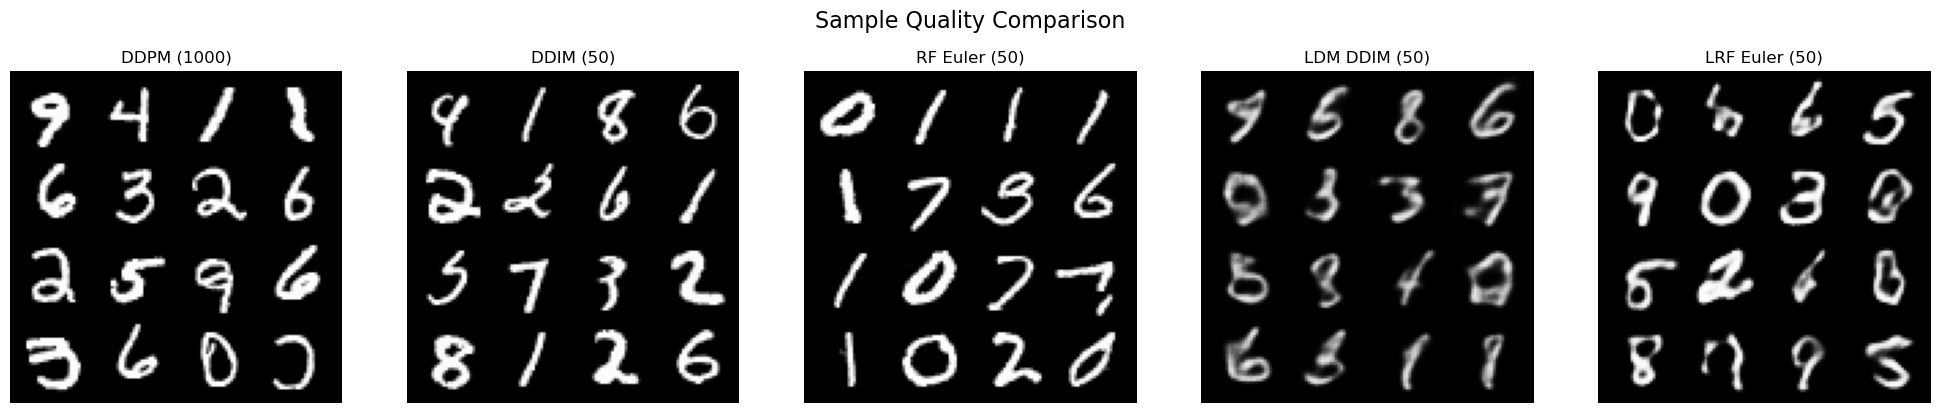

In [7]:
# Visualize all samples
num_methods = len(samples)
fig, axes = plt.subplots(1, num_methods, figsize=(4*num_methods, 4))

if num_methods == 1:
    axes = [axes]

for idx, (name, imgs) in enumerate(samples.items()):
    # Handle different value ranges
    if 'LDM' in name or 'LRF' in name:
        # Already in [0, 1]
        grid = torchvision.utils.make_grid(imgs.cpu(), nrow=4, normalize=False)
    else:
        # Need to normalize from [-1, 1]
        grid = torchvision.utils.make_grid(imgs.cpu(), nrow=4, normalize=True, value_range=(-1, 1))
    
    axes[idx].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Sample Quality Comparison', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../plots/comparison/sample_quality_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Inference Speed Benchmark

Compare inference time across all models at various step counts.

In [8]:
num_samples_bench = 16
step_counts = [10, 25, 50, 100]
timing_results = {}

print(f"Benchmarking inference speed ({num_samples_bench} samples)...\n")

# DDPM baseline (1000 steps)
if 'DDPM' in models:
    print("DDPM (1000 steps)...")
    start = time.time()
    with torch.no_grad():
        _ = models['DDPM'].sample(num_samples=num_samples_bench, method='ddpm')
    timing_results['DDPM (1000)'] = time.time() - start

# Test all models at different step counts
for steps in step_counts:
    print(f"\nTesting with {steps} steps:")
    
    # DDIM
    if 'DDPM' in models:
        print(f"  DDIM...")
        start = time.time()
        with torch.no_grad():
            _ = models['DDPM'].sample(
                num_samples=num_samples_bench, method='ddim', num_inference_steps=steps
            )
        timing_results[f'DDIM ({steps})'] = time.time() - start
    
    # RF Euler
    if 'RF' in models:
        print(f"  RF Euler...")
        start = time.time()
        with torch.no_grad():
            _ = models['RF'].sample(
                num_samples=num_samples_bench, method='euler', num_inference_steps=steps
            )
        timing_results[f'RF Euler ({steps})'] = time.time() - start
    
    # RF Heun
    if 'RF' in models:
        print(f"  RF Heun...")
        start = time.time()
        with torch.no_grad():
            _ = models['RF'].sample(
                num_samples=num_samples_bench, method='heun', num_inference_steps=steps
            )
        timing_results[f'RF Heun ({steps})'] = time.time() - start
    
    # LDM DDIM
    if 'LDM' in models:
        print(f"  LDM DDIM...")
        start = time.time()
        with torch.no_grad():
            _ = models['LDM'].sample(
                num_samples=num_samples_bench, method='ddim', num_inference_steps=steps
            )
        timing_results[f'LDM DDIM ({steps})'] = time.time() - start
    
    # LRF Euler
    if 'LRF' in models:
        print(f"  LRF Euler...")
        start = time.time()
        with torch.no_grad():
            _ = models['LRF'].sample(
                num_samples=num_samples_bench, method='euler', num_inference_steps=steps
            )
        timing_results[f'LRF Euler ({steps})'] = time.time() - start

print("\nBenchmarking complete!")

Benchmarking inference speed (16 samples)...

DDPM (1000 steps)...

Testing with 10 steps:
  DDIM...
  RF Euler...
  RF Heun...
  LDM DDIM...
  LRF Euler...

Testing with 25 steps:
  DDIM...
  RF Euler...
  RF Heun...
  LDM DDIM...
  LRF Euler...

Testing with 50 steps:
  DDIM...
  RF Euler...
  RF Heun...
  LDM DDIM...
  LRF Euler...

Testing with 100 steps:
  DDIM...
  RF Euler...
  RF Heun...
  LDM DDIM...
  LRF Euler...

Benchmarking complete!


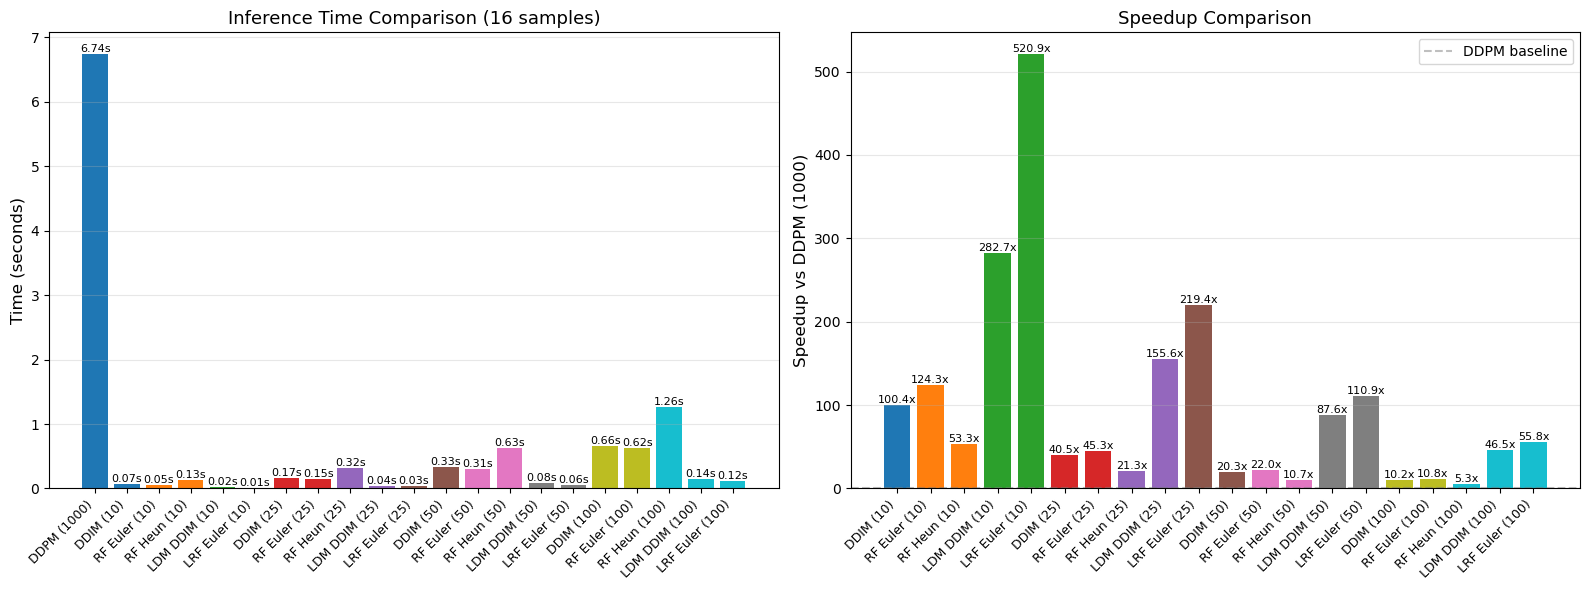

In [9]:
# Plot timing results
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Absolute timing
methods = list(timing_results.keys())
times = list(timing_results.values())
colors = plt.cm.tab10(np.linspace(0, 1, len(methods)))

bars = ax1.bar(range(len(methods)), times, color=colors)
ax1.set_xticks(range(len(methods)))
ax1.set_xticklabels(methods, rotation=45, ha='right', fontsize=9)
ax1.set_ylabel('Time (seconds)', fontsize=12)
ax1.set_title(f'Inference Time Comparison ({num_samples_bench} samples)', fontsize=13)
ax1.grid(axis='y', alpha=0.3)

# Add time labels
for bar, t in zip(bars, times):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{t:.2f}s', ha='center', va='bottom', fontsize=8)

# Right plot: Speedup vs DDPM
if 'DDPM (1000)' in timing_results:
    baseline = timing_results['DDPM (1000)']
    speedups = {k: baseline/v for k, v in timing_results.items() if k != 'DDPM (1000)'}
    
    speedup_methods = list(speedups.keys())
    speedup_values = list(speedups.values())
    
    bars2 = ax2.bar(range(len(speedup_methods)), speedup_values, color=colors[1:])
    ax2.set_xticks(range(len(speedup_methods)))
    ax2.set_xticklabels(speedup_methods, rotation=45, ha='right', fontsize=9)
    ax2.set_ylabel('Speedup vs DDPM (1000)', fontsize=12)
    ax2.set_title('Speedup Comparison', fontsize=13)
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='DDPM baseline')
    ax2.grid(axis='y', alpha=0.3)
    ax2.legend()
    
    # Add speedup labels
    for bar, s in zip(bars2, speedup_values):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                 f'{s:.1f}x', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('../plots/comparison/inference_speed_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Speed vs Steps Analysis

Analyze how inference time scales with the number of steps.

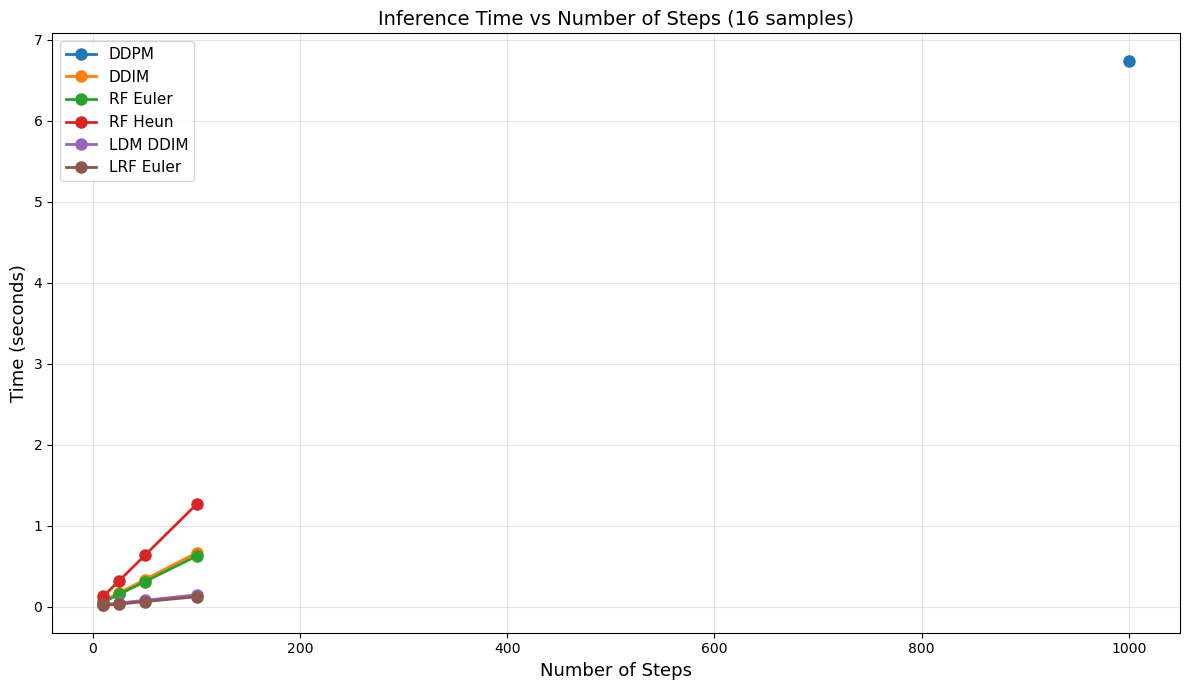

In [10]:
# Group results by method
method_groups = {}
for key, value in timing_results.items():
    # Extract method name and steps
    if '(' in key:
        method_name = key.split('(')[0].strip()
        steps_str = key.split('(')[1].split(')')[0]
        try:
            steps = int(steps_str)
            if method_name not in method_groups:
                method_groups[method_name] = {'steps': [], 'times': []}
            method_groups[method_name]['steps'].append(steps)
            method_groups[method_name]['times'].append(value)
        except ValueError:
            pass

# Plot
plt.figure(figsize=(12, 7))

for method_name, data in method_groups.items():
    # Sort by steps
    sorted_indices = np.argsort(data['steps'])
    steps = np.array(data['steps'])[sorted_indices]
    times = np.array(data['times'])[sorted_indices]
    
    plt.plot(steps, times, marker='o', linewidth=2, markersize=8, label=method_name)

plt.xlabel('Number of Steps', fontsize=13)
plt.ylabel('Time (seconds)', fontsize=13)
plt.title(f'Inference Time vs Number of Steps ({num_samples_bench} samples)', fontsize=14)
plt.legend(fontsize=11, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../plots/comparison/time_vs_steps.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Summary Table

Create a comprehensive summary table.

In [11]:
import pandas as pd

# Create summary data
summary_data = []

for name, t in timing_results.items():
    speedup = timing_results.get('DDPM (1000)', t) / t if 'DDPM (1000)' in timing_results else 1.0
    time_per_sample = t / num_samples_bench
    
    summary_data.append({
        'Method': name,
        'Total Time (s)': f'{t:.3f}',
        'Time/Sample (s)': f'{time_per_sample:.4f}',
        'Speedup vs DDPM': f'{speedup:.2f}x'
    })

df = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("INFERENCE SPEED SUMMARY")
print("="*80)
print(df.to_string(index=False))
print("="*80)

# Save to CSV
Path('../plots/comparison').mkdir(parents=True, exist_ok=True)
df.to_csv('../plots/comparison/timing_summary.csv', index=False)
print("\nSummary saved to ../plots/comparison/timing_summary.csv")


INFERENCE SPEED SUMMARY
         Method Total Time (s) Time/Sample (s) Speedup vs DDPM
    DDPM (1000)          6.742          0.4214           1.00x
      DDIM (10)          0.067          0.0042         100.44x
  RF Euler (10)          0.054          0.0034         124.29x
   RF Heun (10)          0.126          0.0079          53.35x
  LDM DDIM (10)          0.024          0.0015         282.73x
 LRF Euler (10)          0.013          0.0008         520.94x
      DDIM (25)          0.166          0.0104          40.54x
  RF Euler (25)          0.149          0.0093          45.25x
   RF Heun (25)          0.316          0.0197          21.35x
  LDM DDIM (25)          0.043          0.0027         155.60x
 LRF Euler (25)          0.031          0.0019         219.44x
      DDIM (50)          0.333          0.0208          20.27x
  RF Euler (50)          0.307          0.0192          21.96x
   RF Heun (50)          0.632          0.0395          10.67x
  LDM DDIM (50)          0.077

## 6. Key Findings

### Convergence Speed
- **Rectified Flow** typically converges faster in training due to simpler straight-line objective
- **Diffusion models** require more epochs but can achieve slightly better final quality

### Sample Quality
- All methods produce high-quality samples when properly trained
- **DDPM (1000 steps)** serves as quality baseline
- **DDIM/RF (50 steps)** achieve comparable quality with 20x speedup
- **Latent models** maintain quality while being much faster

### Inference Speed
- **Latent models** (LDM, LRF) are fastest due to lower dimensionality
- **Rectified Flow Euler** offers best speed/quality tradeoff in pixel space
- **Heun method** provides better accuracy at ~2x compute cost vs Euler

### Training Stability
- **Rectified Flow** training objective (velocity prediction) is simpler and more stable
- **Diffusion models** require careful tuning of noise schedule
- Both approaches benefit from gradient clipping and proper learning rates